# VehiclePositions EDA Sandbox

This notebook explores GTFS-RT `VehiclePositions` for one day and tests practical join strategies to TripUpdates-derived arrivals.

## Goals
1. Parse `VehiclePositions/muni/<day>/*.pb` into a flat dataframe.
2. Understand key coverage (`vehicle_id`, `trip_id`, `current_stop_sequence`, timestamps).
3. Test candidate joins to TripUpdates condensed output.
4. Measure match rates and time deltas.

## Data source
- Bucket path: `511_transit_data/VehiclePositions/muni/2026-06-23`

## Notes
- Use feed header timestamp as primary snapshot timestamp.
- Use filename timestamp as fallback.
- This notebook is exploratory and optimized for learning.

In [5]:
from google.cloud import storage
from google.transit import gtfs_realtime_pb2
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------
# Step 1: Run configuration
# ------------------------------
agency_id = "muni"
service_date = "2026-06-23"
bucket_name = "511_transit_data"
vp_prefix = f"VehiclePositions/{agency_id}/{service_date}/"

# Optional sampling for faster iteration.
sample_mode = True
sample_n_blobs = 200
sample_every_k = None  # e.g. 10 for every 10th blob

# Optional path to TripUpdates condensed parquet from your transform notebook.
tripupdates_latest_path = Path(f"trip_stop_prediction_latest_{agency_id}_{service_date}.parquet")

print(f"VehiclePositions prefix: {vp_prefix}")
print(f"Sample mode: {sample_mode}")
print(f"sample_n_blobs: {sample_n_blobs}")
print(f"sample_every_k: {sample_every_k}")
print(f"TripUpdates latest parquet exists: {tripupdates_latest_path.exists()}")

/Users/patri/miniconda3/envs/nachos/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


VehiclePositions prefix: VehiclePositions/muni/2026-06-23/
Sample mode: True
sample_n_blobs: 200
sample_every_k: None
TripUpdates latest parquet exists: False


## Step 2 - Discover VehiclePositions blobs for the day

This creates a manifest and the selected blob subset for parsing.

In [6]:
def parse_snapshot_ts_from_blob_name(blob_name: str) -> pd.Timestamp:
    ts_text = blob_name.rsplit("/", 1)[-1].replace(".pb", "")
    return pd.to_datetime(
        ts_text, format="%Y-%m-%dT%H-%M-%S.%fZ", utc=True, errors="coerce"
    )


client = storage.Client()
vp_blobs = list(client.list_blobs(bucket_name, prefix=vp_prefix))

print(f"Found {len(vp_blobs):,} VehiclePositions blobs")
if not vp_blobs:
    raise ValueError("No VehiclePositions blobs found for this date/prefix.")

vp_manifest = pd.DataFrame(
    {
        "blob_order": range(len(vp_blobs)),
        "blob_name": [b.name for b in vp_blobs],
    }
)
vp_manifest["filename_snapshot_ts"] = vp_manifest["blob_name"].map(parse_snapshot_ts_from_blob_name)

vp_parse_manifest = vp_manifest.copy()
if sample_mode:
    if sample_every_k is not None and sample_every_k > 1:
        vp_parse_manifest = vp_parse_manifest.iloc[::sample_every_k].copy()
    vp_parse_manifest = vp_parse_manifest.head(sample_n_blobs).copy()

vp_parse_blob_orders = vp_parse_manifest["blob_order"].tolist()
vp_parse_blobs = [vp_blobs[i] for i in vp_parse_blob_orders]

print(f"Blobs selected for parse: {len(vp_parse_blobs):,}")
display(vp_parse_manifest.head())
print("Missing filename timestamp parses:", vp_parse_manifest["filename_snapshot_ts"].isna().sum())

Found 1,438 VehiclePositions blobs
Blobs selected for parse: 200


,blob_order,blob_name,filename_snapshot_ts
0,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52.051568+00:00
1,1,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:01:59.772002+00:00
2,2,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:04:03.594376+00:00
3,3,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:04:10.994943+00:00
4,4,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:05:10.713848+00:00


Missing filename timestamp parses: 0


## Step 3 - Parse protobuf VehiclePositions into a flat dataframe

One row per vehicle position observation with trip/vehicle context and location context.

In [7]:
vp_rows = []

for blob_order, blob in tqdm(
    zip(vp_parse_blob_orders, vp_parse_blobs),
    total=len(vp_parse_blobs),
    desc="Parsing VehiclePositions",
):
    feed = gtfs_realtime_pb2.FeedMessage()
    feed.ParseFromString(blob.download_as_bytes())

    filename_snapshot_ts = parse_snapshot_ts_from_blob_name(blob.name)
    header_snapshot_ts = pd.NaT
    if feed.HasField("header") and feed.header.HasField("timestamp"):
        header_snapshot_ts = pd.to_datetime(feed.header.timestamp, unit="s", utc=True, errors="coerce")

    if pd.notna(header_snapshot_ts):
        snapshot_ts = header_snapshot_ts
        snapshot_ts_source = "header"
    else:
        snapshot_ts = filename_snapshot_ts
        snapshot_ts_source = "filename_fallback"

    for entity in feed.entity:
        if not entity.HasField("vehicle"):
            continue

        vp = entity.vehicle
        trip = vp.trip
        vehicle = vp.vehicle
        position = vp.position

        trip_id = trip.trip_id if trip.trip_id else None
        route_id = trip.route_id if trip.route_id else None
        direction_id = trip.direction_id if trip.HasField("direction_id") else None
        current_stop_sequence = vp.current_stop_sequence if vp.HasField("current_stop_sequence") else None
        stop_id = vp.stop_id if vp.stop_id else None
        current_status = vp.current_status if vp.HasField("current_status") else None

        vehicle_id = vehicle.id if vehicle.id else None
        vehicle_label = vehicle.label if vehicle.label else None

        position_timestamp = pd.NaT
        if vp.HasField("timestamp"):
            position_timestamp = pd.to_datetime(vp.timestamp, unit="s", utc=True, errors="coerce")

        latitude = position.latitude if vp.HasField("position") and position.HasField("latitude") else None
        longitude = position.longitude if vp.HasField("position") and position.HasField("longitude") else None
        bearing = position.bearing if vp.HasField("position") and position.HasField("bearing") else None
        speed = position.speed if vp.HasField("position") and position.HasField("speed") else None

        vp_rows.append(
            {
                "agency_id": agency_id,
                "blob_order": blob_order,
                "blob_name": blob.name,
                "snapshot_ts": snapshot_ts,
                "snapshot_ts_source": snapshot_ts_source,
                "position_timestamp": position_timestamp,
                "trip_id": trip_id,
                "route_id": route_id,
                "direction_id": direction_id,
                "current_stop_sequence": current_stop_sequence,
                "stop_id": stop_id,
                "current_status": current_status,
                "vehicle_id": vehicle_id,
                "vehicle_label": vehicle_label,
                "latitude": latitude,
                "longitude": longitude,
                "bearing": bearing,
                "speed": speed,
            }
        )

df_vp_raw = pd.DataFrame(vp_rows)
print(f"Vehicle position rows: {len(df_vp_raw):,}")
print("Snapshot source counts:")
display(df_vp_raw["snapshot_ts_source"].value_counts(dropna=False))
display(df_vp_raw.head())

Parsing VehiclePositions:   0%|          | 0/200 [00:00<?, ?it/s]

Vehicle position rows: 136,923
Snapshot source counts:


snapshot_ts_source
header    136923
Name: count, dtype: int64

,agency_id,blob_order,blob_name,snapshot_ts,snapshot_ts_source,position_timestamp,trip_id,route_id,direction_id,current_stop_sequence,stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed
0,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,1,1,37.794949,-122.412209,0.0,0.00
1,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,10,10,37.794739,-122.410042,0.0,0.00
2,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081054_M41,F,1.0,30.0,15184,0.0,1010,1010,37.807434,-122.417427,0.0,0.00
3,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12080952_M41,F,0.0,27.0,15690,1.0,1015,1015,37.766357,-122.430496,210.0,6.39
4,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081057_M41,F,1.0,13.0,15645,2.0,1050,1050,37.781578,-122.411156,30.0,7.50


## Step 4 - Basic EDA on join key coverage

This helps answer: *Do we have enough key coverage to join reliably?*

In [8]:
if df_vp_raw.empty:
    raise ValueError("df_vp_raw is empty. Run parse cells first.")

coverage = pd.Series(
    {
        "rows": len(df_vp_raw),
        "trip_id_null_rate": df_vp_raw["trip_id"].isna().mean(),
        "vehicle_id_null_rate": df_vp_raw["vehicle_id"].isna().mean(),
        "current_stop_sequence_null_rate": df_vp_raw["current_stop_sequence"].isna().mean(),
        "stop_id_null_rate": df_vp_raw["stop_id"].isna().mean(),
        "snapshot_ts_null_rate": df_vp_raw["snapshot_ts"].isna().mean(),
        "position_timestamp_null_rate": df_vp_raw["position_timestamp"].isna().mean(),
    }
)
print("VehiclePositions key coverage:")
display(coverage)

print("Unique counts:")
print("trip_id:", df_vp_raw["trip_id"].nunique(dropna=True))
print("vehicle_id:", df_vp_raw["vehicle_id"].nunique(dropna=True))
print("route_id:", df_vp_raw["route_id"].nunique(dropna=True))

print("Current status distribution:")
display(df_vp_raw["current_status"].value_counts(dropna=False).head(10))

VehiclePositions key coverage:


rows                               136923.000000
trip_id_null_rate                       0.301505
vehicle_id_null_rate                    0.000000
current_stop_sequence_null_rate         0.305975
stop_id_null_rate                       0.305975
snapshot_ts_null_rate                   0.000000
position_timestamp_null_rate            0.000000
dtype: float64

Unique counts:
trip_id: 2099
vehicle_id: 779
route_id: 59
Current status distribution:


current_status
NaN    41895
2.0    38104
1.0    37802
0.0    19122
Name: count, dtype: int64

Position timestamp minus snapshot timestamp (seconds):


count    136923.000000
mean         -8.019069
std           4.458655
min         -16.000000
5%          -15.000000
25%         -12.000000
50%          -8.000000
75%          -4.000000
95%          -1.000000
max           0.000000
Name: position_vs_snapshot_sec, dtype: float64

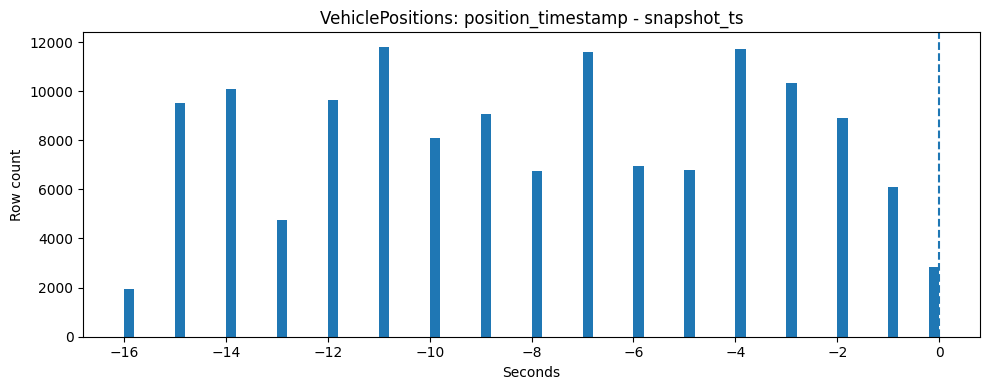

In [9]:
# Quick look at how far position timestamps are from snapshot timestamps.
# This can indicate stale position payloads.

tmp = df_vp_raw.copy()
tmp["position_vs_snapshot_sec"] = (
    tmp["position_timestamp"] - tmp["snapshot_ts"]
).dt.total_seconds()

print("Position timestamp minus snapshot timestamp (seconds):")
display(tmp["position_vs_snapshot_sec"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

plt.figure(figsize=(10, 4))
plot_vals = tmp["position_vs_snapshot_sec"].dropna()
if not plot_vals.empty:
    plt.hist(plot_vals, bins=80)
    plt.title("VehiclePositions: position_timestamp - snapshot_ts")
    plt.xlabel("Seconds")
    plt.ylabel("Row count")
    plt.axvline(0, linestyle="--")
    plt.tight_layout()
    plt.show()
else:
    print("No non-null position_vs_snapshot_sec values to plot.")

## Step 5 - Load TripUpdates condensed output for join testing

This expects the parquet generated by your TripUpdates transform notebook.

In [10]:
raw_dir = Path("../data/parquet/tripupdates_raw/muni_2026-06-23")
part_files = sorted(raw_dir.glob("part-*.parquet"))
df_tu_latest = pd.concat((pd.read_parquet(p) for p in part_files), ignore_index=True)

In [14]:
df_tu_latest.head()
df_vp_raw.head()

,agency_id,blob_order,blob_name,snapshot_ts,snapshot_ts_source,position_timestamp,trip_id,route_id,direction_id,current_stop_sequence,stop_id,current_status,vehicle_id,vehicle_label,latitude,longitude,bearing,speed
0,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,1,1,37.794949,-122.412209,0.0,0.00
1,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,None,None,NaN,NaN,None,NaN,10,10,37.794739,-122.410042,0.0,0.00
2,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081054_M41,F,1.0,30.0,15184,0.0,1010,1010,37.807434,-122.417427,0.0,0.00
3,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12080952_M41,F,0.0,27.0,15690,1.0,1015,1015,37.766357,-122.430496,210.0,6.39
4,muni,0,VehiclePositions/muni/2026-06-23/2026-06-23T00...,2026-06-23 00:00:52+00:00,header,2026-06-23 00:00:51+00:00,12081057_M41,F,1.0,13.0,15645,2.0,1050,1050,37.781578,-122.411156,30.0,7.50


## Step 6 - Join strategy A: `trip_id + stop_sequence + nearest timestamp`

This strategy does not require `vehicle_id` in TripUpdates.

Interpretation:
- For each vehicle position row, find the nearest TripUpdates latest row with same `trip_id` and same stop sequence.
- Use a time tolerance to avoid implausible links.

In [ ]:
# Replacement for the previous join cell (fixes sort/order issues for merge_asof).
join_tolerance = pd.Timedelta("10min")

vp_join = df_vp_raw[
    [
        "snapshot_ts",
        "position_timestamp",
        "trip_id",
        "vehicle_id",
        "route_id",
        "current_stop_sequence",
        "stop_id",
        "latitude",
        "longitude",
    ]
].copy()
vp_join = vp_join.rename(columns={"snapshot_ts": "vp_snapshot_ts"})
vp_join = vp_join.dropna(subset=["trip_id", "current_stop_sequence", "vp_snapshot_ts"]).copy()
vp_join["current_stop_sequence"] = vp_join["current_stop_sequence"].astype(int)

# TripUpdates time column can vary based on how df_tu_latest was built.
tu_ts_col = "latest_snapshot_ts" if "latest_snapshot_ts" in df_tu_latest.columns else "snapshot_ts"

tu_join = df_tu_latest[
    [
        "trip_id",
        "stop_sequence",
        "stop_id",
        tu_ts_col,
        "arrival_time_predicted",
        "departure_time_predicted",
        "route_id",
        "direction_id",
    ]
].copy()
tu_join = tu_join.rename(
    columns={
        "stop_sequence": "current_stop_sequence",
        "stop_id": "tu_stop_id",
        "route_id": "tu_route_id",
    }
)
tu_join = tu_join.dropna(subset=["trip_id", "current_stop_sequence", tu_ts_col]).copy()
tu_join["current_stop_sequence"] = tu_join["current_stop_sequence"].astype(int)

# Critical: sort by timestamp first for merge_asof.
vp_join = vp_join.sort_values(["vp_snapshot_ts", "trip_id", "current_stop_sequence"])
tu_join = tu_join.sort_values([tu_ts_col, "trip_id", "current_stop_sequence"])

joined_a = pd.merge_asof(
    left=vp_join,
    right=tu_join,
    left_on="vp_snapshot_ts",
    right_on=tu_ts_col,
    by=["trip_id", "current_stop_sequence"],
    direction="nearest",
    tolerance=join_tolerance,
)

joined_a["matched"] = joined_a[tu_ts_col].notna()
joined_a["join_time_delta_sec"] = (
    joined_a["vp_snapshot_ts"] - joined_a[tu_ts_col]
).dt.total_seconds()

match_rate = joined_a["matched"].mean()
print(f"Join strategy A rows: {len(joined_a):,}")
print(f"Join strategy A match rate: {match_rate:.2%}")

print("Join delta (seconds) summary for matched rows:")
display(
    joined_a.loc[joined_a["matched"], "join_time_delta_sec"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
)

display(joined_a.head())

In [13]:
join_tolerance = pd.Timedelta("10min")

vp_join = df_vp_raw[
    [
        "snapshot_ts",
        "position_timestamp",
        "trip_id",
        "vehicle_id",
        "route_id",
        "current_stop_sequence",
        "stop_id",
        "latitude",
        "longitude",
    ]
].copy()

# Use snapshot_ts for alignment; could also experiment with position_timestamp.
vp_join = vp_join.rename(columns={"snapshot_ts": "vp_snapshot_ts"})
vp_join = vp_join.dropna(subset=["trip_id", "current_stop_sequence", "vp_snapshot_ts"]).copy()
vp_join["current_stop_sequence"] = vp_join["current_stop_sequence"].astype(int)


tu_join = df_tu_latest[
    [
        "trip_id",
        "stop_sequence",
        "stop_id",
        "snapshot_ts",
        "arrival_time_predicted",
        "departure_time_predicted",
        "route_id",
        "direction_id",
    ]
].copy()
tu_join = tu_join.rename(
    columns={
        "stop_sequence": "current_stop_sequence",
        "stop_id": "tu_stop_id",
        "route_id": "tu_route_id",
    }
)
tu_join = tu_join.dropna(subset=["trip_id", "current_stop_sequence", "snapshot_ts"]).copy()
tu_join["current_stop_sequence"] = tu_join["current_stop_sequence"].astype(int)

vp_join = vp_join.sort_values(["trip_id", "current_stop_sequence", "vp_snapshot_ts"])
tu_join = tu_join.sort_values(["trip_id", "current_stop_sequence", "snapshot_ts"])

joined_a = pd.merge_asof(
    left=vp_join,
    right=tu_join,
    left_on="vp_snapshot_ts",
    right_on="snapshot_ts",
    by=["trip_id", "current_stop_sequence"],
    direction="nearest",
    tolerance=join_tolerance,
)

joined_a["matched"] = joined_a["latest_snapshot_ts"].notna()
joined_a["join_time_delta_sec"] = (
    joined_a["vp_snapshot_ts"] - joined_a["latest_snapshot_ts"]
).dt.total_seconds()

match_rate = joined_a["matched"].mean()
print(f"Join strategy A rows: {len(joined_a):,}")
print(f"Join strategy A match rate: {match_rate:.2%}")

print("Join delta (seconds) summary for matched rows:")
display(joined_a.loc[joined_a["matched"], "join_time_delta_sec"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

display(joined_a.head())

ValueError: left keys must be sorted

In [ ]:
# Inspect unmatched rows to understand failure modes.
unmatched_a = joined_a[~joined_a["matched"]].copy()
print(f"Unmatched rows (strategy A): {len(unmatched_a):,}")

if not unmatched_a.empty:
    print("Top unmatched trip_ids:")
    display(unmatched_a["trip_id"].value_counts().head(20))

    print("Null-rate snapshot for unmatched rows:")
    display(
        unmatched_a[
            ["trip_id", "vehicle_id", "current_stop_sequence", "vp_snapshot_ts", "stop_id"]
        ].isna().mean()
    )

    print("Sample unmatched rows:")
    display(unmatched_a.head(20))

## Step 7 - What to test next

- Tighten or relax `join_tolerance` and monitor match rate vs false matches.
- Compare using `position_timestamp` instead of `vp_snapshot_ts` for the as-of join.
- Add route consistency checks (`route_id` in VP vs TU) after matching.
- If you want the most reliable "specific vehicle on this trip-stop" join, include `vehicle_id` in your TripUpdates transform output and then test `vehicle_id + trip_id + nearest timestamp`.